In [1]:
import myBM as bm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import analytics as an
#import BA_full_code as ben
hbarvf = 0.6852

20 32


In [14]:
CUTOFF = 10
POTENTIALSTRENGTH = -0.11
SHAPE = "hexagonal"
lat = np.asarray(bm.build_lattice(CUTOFF,shape=SHAPE))
adj = bm.build_adjacency_matrix(lat)
N = len(lat)
#benscoords = ben.make_shell_3(1,1)
#kθ,_ = ben.find_moire_vetors(1)
#benscoords = np.asarray(benscoords)
print(len(lat))
#print(benscoords.shape)
#benslattice = benscoords[:,0,None]*bm.q1[None]+benscoords[:,1,None]*bm.q2[None]+benscoords[:,2,None]*bm.q3[None]

367


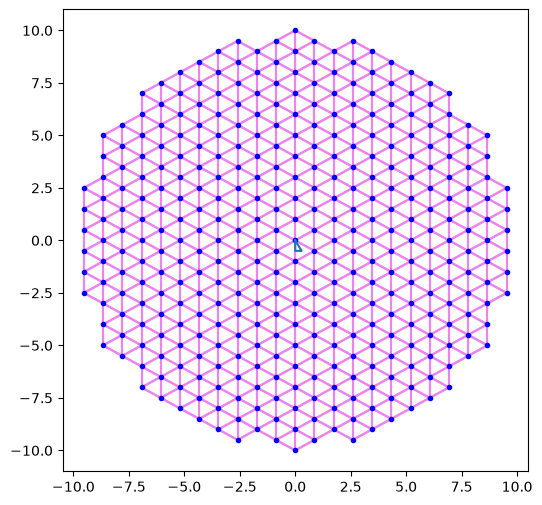

In [15]:
fig,ax = plt.subplots(figsize=(6,6))

for i in range(N):
    for j in range(N):
        if adj[i,j]==1:
            bondx = [lat[i][0],lat[j][0]]
            bondy = [lat[i][1],lat[j][1]]
            ax.plot(bondx,bondy,c='violet')
for p in lat:
    ax.plot(*p,marker='.',c='b')
shift = -bm.q3
translattice = bm.translate_lattice(lat,shift)
#latticeplot = ax.scatter(lat[:,0],lat[:,1],zorder=2,c=np.arange(len(lat)),cmap='seismic',vmin=0,vmax=N-1)
#latticeplot2 = ax.scatter(lat[:,0],lat[:,1],s=10,zorder=3,c=translattice,marker='s',cmap='seismic',vmin=0,vmax=N-1)
#plt.colorbar(latticeplot)

#for p in benslattice:
    #ax.plot(*p,marker='x',c='crimson')
ax.plot(bm.hexagonalpath[:,0],bm.hexagonalpath[:,1],linestyle='solid',marker='',markersize=2)


In [16]:
#H1 = bm.H_along_path(0.45,cutoff=10)
#print("Built hamiltonian.")
#E1 = np.linalg.eigvalsh(H1)
θ=0.72
phases = np.exp(1j*np.pi/8*np.array([0,1,2]))
H = bm.H_along_path(θ,cutoff=CUTOFF,w=POTENTIALSTRENGTH,shape=SHAPE,phases=None)
print("Built hamiltonian.")
E,U = np.linalg.eigh(H)
kθ = bm.get_q(θ/180*np.pi)
#Hb,Nb = ben.build_H_scattering(kθ*bm.path[:,0],kθ*bm.path[:,1],θ,10,110)
#print("Built Ben's Hamiltonian.")
#print(np.shape(H2))
#Eb = np.linalg.eigvalsh(Hb)

#plt.plot(Eb/1000,c='deepskyblue')
#k_rad = kθ*np.linalg.norm(bm.hexagonalpath[5])
#berryphase = bm.berry_phase(k_rad,0.175,q=kθ,w=POTENTIALSTRENGTH,cutoff=CUTOFF)
###ALT:
H_alt = bm.H_along_path(θ,cutoff=CUTOFF,w=0*POTENTIALSTRENGTH,shape=SHAPE,phases=None)
print("Built hamiltonian.")
E_alt,U_alt = np.linalg.eigh(H_alt)

0.21401619774878664
Built hamiltonian.
0.21401619774878664
Built hamiltonian.


0.19471843536095254


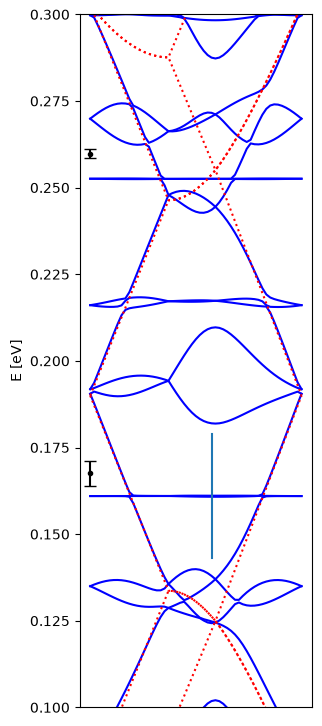

In [19]:
λ,offset = an.linear_potential_fit(θ,-POTENTIALSTRENGTH)
E_Q=[]
Γ = []
for i in range(7):
    mval = 3.5+i
    E_quantized,n = an.quantization(1/2,m=mval,λ=λ)
    Tcoeff = np.sqrt(2)*np.exp(-an.integral(wave='evanescent',m=mval,E=E_quantized,λ=λ))
    #print(Tcoeff)
    decay = an.decayrate(E=E_quantized,T=Tcoeff,m=mval,λ=λ)
    Γ.append(decay)
    E_Q.append(E_quantized)
E_lowest = E[:,np.argsort(abs(E[0]))[:55]]
plt.subplots(figsize=(3,9))
plt.errorbar(0+np.zeros(7),np.asarray(E_Q)-offset,yerr=Γ,c='black',fmt='.',capsize=4)
plt.plot(E,c='blue',linestyle='solid',marker='')
plt.plot(0.8*E_alt+0.19,c='red',linestyle='dotted')
plt.ylim(0.1,0.3)
plt.ylabel("E [eV]")
plt.xticks([])
prop = (0.6582*4*kθ*0.11*np.pi)
print(prop)
#E_an = an.quasibound_spectrum
#δE_an = an.quasi_bound_decayrates
#plt.plot(np.zeros(8),np.sqrt(prop*np.arange(3,11))-0.86,marker='.',c='r',linestyle='None')
flatbands = np.array([0.112,0.216,0.313,0.404,0.49,0.570,0.639])
#plt.plot(np.zeros(len(flatbands)),flatbands,linestyle='None',c='black',marker='o')
#plt.plot(np.zeros(len(E_an)),E_an-0.86,linestyle='None',c='gold',marker='o')
#plt.plot([0,]*len(E_Q),np.asarray(E_Q)-0.86,marker='.',c='gold',linestyle='None')
#plt.savefig("./plots/bandstructure_electron_like.pdf",bbox_inches='tight')
#plt.savefig("./plots/semiclassical_energies.pdf",bbox_inches='tight')
δ=0.018
plt.plot([31,31,31],[0.161-δ,0.161,0.161+δ],marker='None')

#print(f"Berry phase of cone is {berryphase}.")

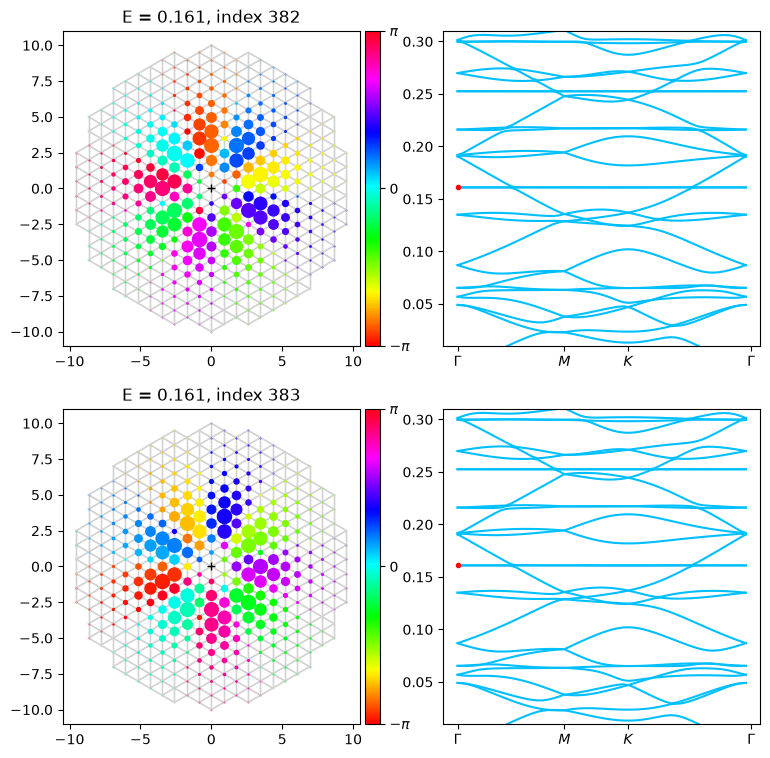

In [20]:
momentum_index = 0
flatband_energy = 0.16 #eV
fig,ax = bm.visualize_flatbands(U,E,flatband_energy,
                                momentum_index,lat,adj,scale=800,δ=0,
                               scale_absolute=1,scale_relative=0)

In [8]:
ind1,ind2 = 256,257

momentum_index = 0
Ushifted = bm.zoneshift(U[...,ind1],-4*bm.q1)
u1,u2 = U[momentum_index,:,ind1],U[momentum_index,:,ind2]
print(u1.shape,u2.shape)
#print(u1.shape)
rot = bm.rotationMatrix(2*np.pi/3,lat)
repmat = bm.rotationRepresentation((u1,u2),rot)
print(np.round(repmat,3))
eigvals = np.linalg.eigvals(repmat)
print((eigvals))
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(9,4))
bm.plot_wavefunction(u1,ax1,lat,scale=800,scale_relative=0)
bm.plot_wavefunction(u2,ax2,lat,scale=800,scale_relative=0)
print(np.exp(1j*2*np.pi/3))
print(H[0].shape)
commutator = H[momentum_index]@rot-rot@H[momentum_index]
print(np.sum(abs(commutator)))


TypeError: cannot unpack non-iterable int object

# Log of tangerine states
These half-integer angular momentum bound states appear at (For θ=0.8, w=0.11, cutoff=8):  

    l=1 E[263,262]=0.296 (Not flat)
    l=3 E[247,246]=0.137 (Not flat)
    l=5 E[237,236]=0.0059 (Not flat)
    l=7 E[231,230]=-0.112 (Flat)
    l=9 E[225,224]=-0.216 (Flat)
    l=11 E[217,216]=-0.313 (Flat)
    l=13 E[205,204]=-0.404 (Flat)
    l=15 E[195,194]=-0.490 (Mostly Flat)
    l=17 E[183,183]=-0.570 (Kind of Flat)
    l=19 E[173,172]=-0.639 (Starting to disassociate)

(55, 734, 734)
0.07395868860564893
1.0075525520716302
0.07395868860564893
6.811590166531657
0.16099023367658535


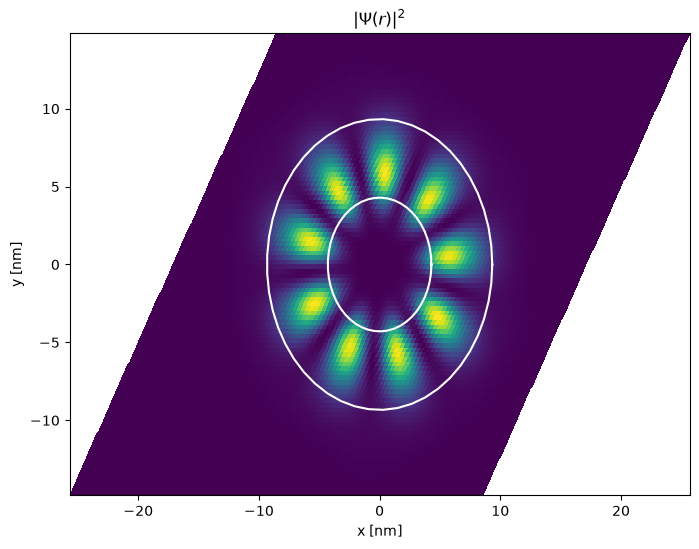

In [21]:
print(U.shape)
ind=383
k_ind=0
angular_m = 9/2
print(λ)
E_classic,n = an.quantization(1/2,m=angular_m,λ=λ)
print(E_classic)
print(λ)
semiclassics = an.classical_regions(E=E_classic,m=angular_m,λ=λ)
r_inner = semiclassics['r0']
r_outer = semiclassics['r1']
#For θ=0.8,w=0.11,cutoff=8:
#263,262,246,247,237,236 | 231,230,225,224,217,216,205,204,195,194,183,182|173,172
print(E[0,ind])
Ψa,Ψb,x,y = bm.wavefunction_realspace(U[k_ind,:,ind],CUTOFF)
fig,ax0 = plt.subplots(1,1,figsize=(8,6))
φa = np.angle(Ψa*Ψb.conj())
φa[abs(Ψa)<0.001]=0
φb = np.angle(Ψb)
φb[abs(Ψb)<0.001]=0
A=ax0.pcolormesh(x/kθ,y/kθ,abs(Ψa)**2,cmap='viridis')
#B=ax1.pcolormesh(x,y,φa,cmap='hsv')
ax0.set_title("$|\\Psi(r)|^2$")
#ax1.set_title("Phase")
#ax0.set_yticks([])
#ax0.set_xticks([])
ax0.set_xlabel("x [nm]")
ax0.set_ylabel("y [nm]")
#ax1.set_yticks([])
#ax1.set_xticks([])
#plt.colorbar(A)
#plt.colorbar(B)
#fig.savefig("./plots/wavefunction_m_8.5.png",bbox_inches='tight')
θ=np.linspace(0,2*np.pi,50)
ax0.plot(r_inner*np.cos(θ),r_inner*np.sin(θ),c='white')
ax0.plot(r_outer*np.cos(θ),r_outer*np.sin(θ),c='white')
#fig.savefig(f"./plots/m_{angular_m}_wavefunction_comparison.pdf",bbox_inches='tight')

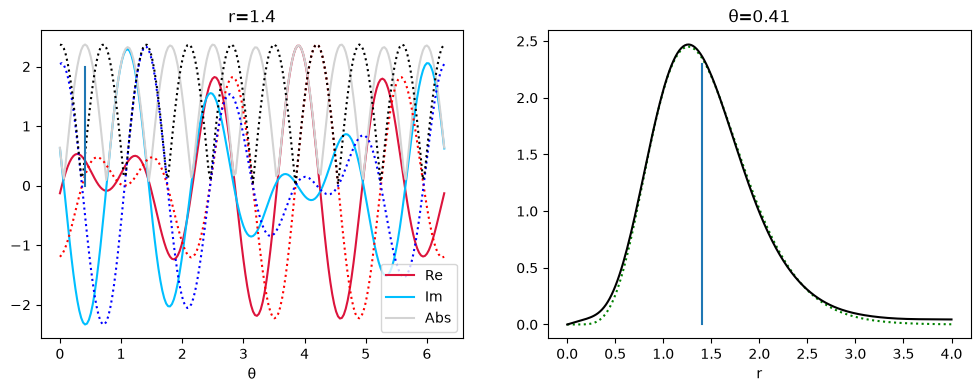

In [30]:
θ =0.41#np.linspace(0,2*np.pi,200)
import analytics as anal
from math import factorial
θarr = np.linspace(0,2*np.pi,200)
fig,(ax0,ax1) = plt.subplots(1,2,figsize=(12,4))
R = np.linspace(0,4,200)
r = 1.4
xr,yr = R*np.cos(θ),R*np.sin(θ)
uA = U[k_ind,::2,ind]
uB = U[k_ind,1::2,ind]


#ax1.plot(R,np.real(ΨAr),c='crimson')
x,y = r*np.cos(θarr),r*np.sin(θarr)
Ψθ = bm.fourier_wavefunction(uA,lat,x,y)
ax0.plot(θarr,np.real(Ψθ),c='crimson',label='Re')
ax0.plot(θarr,np.imag(Ψθ),c='deepskyblue',label='Im')
ax0.plot(θarr,np.abs(Ψθ),c='lightgrey',label='Abs')
#ax0.plot(θarr,np.abs(ΨBθ),c='black')
#plt.plot(θ,np.real(ΨB),c='crimson',linestyle='dotted')
#plt.plot(θ,np.imag(ΨB),c='deepskyblue',linestyle='dotted')
ax0.set_xlabel("θ")
ax1.set_xlabel("r")
ax0.set_title(f"r={r}")
ax1.set_title(f"θ={θ}")
l=9
ζ = np.pi/2*(1+1/l)
a=0.18
def radialfunction(r, l_int, a):
    return r**l_int * np.exp(-(r) / a) / a ** (l_int + 1) / factorial(l_int)
radial = radialfunction(R+1e-18,7,a).astype(complex)
radial/=np.max(abs(radial))
radial*=2.45


#ax1.plot(R,0.4*R)
#ax1.set_ylim(1e-10,2)
#ax0.plot([θ,θ],[0,np.max(abs(Ψθ))])
def angularfunction(θ,m,shift=0):
    angle = θ-shift
    return np.exp(1j*(1/2)*angle)*(np.exp(1j*m/2*angle)+np.exp(-1j*m/2*angle))


angular = 1*(angularfunction(θarr,l,4.2).conj())
angular = angular/np.max(abs(angular))*np.max(abs(Ψθ))
#radial*=-angularfunction(θ,l,3.9).conj()/np.max(abs(angular))
ax1.plot(R,np.abs(radial),c='green',linestyle='dotted')
#ax1.plot(R,np.imag(radial),c='blue',linestyle='dotted')
#ax0.plot(θarr,abs(angular),linestyle='dotted',c='g')
Ψr = bm.fourier_wavefunction(uA,lat,xr,yr)
Ψr*=np.exp(-1j*np.angle(Ψr[np.argmax(abs(Ψr))]))#(-angularfunction(θ,l,3.9))/abs(angularfunction(θ,l,3.9))
#ax1.plot(R,np.imag(ΨAr),c='deepskyblue')
ax1.plot(R,np.abs(Ψr),c='black')
#ax1.plot(R,np.real(Ψr),c='crimson')
#ax1.plot(R,np.imag(Ψr),c='deepskyblue')

#ax1.set_ylim(1e-10,2)
#ax1.plot(R,np.imag(Ψr),c='red')
ax0.plot(θarr,np.real(angular),linestyle='dotted',c='r')
ax0.plot(θarr,np.imag(angular),linestyle='dotted',c='b')
ax0.plot(θarr,np.abs(angular),linestyle='dotted',c='black')

ax0.legend()
ax1.plot([r,r],[0,2.3])
newθ=θarr-1.6
#testing = np.exp(1j*0.)*(0.8*np.exp(1j*4*newθ)+0.4*np.exp(-1j*newθ))
#mismatch = np.angle(Ψθ)
#testing = testing *np.exp(1j*mismatch)
#ax0.plot(θarr,np.imag(testing),linestyle='dotted')
#ax0.plot(θarr,np.real(testing),linestyle='dotted')
ax0.plot([θ,θ],[0,2])
#ax0.set_xlim(2,4)
#ax1.plot(R,0*R)
hydrogen = anal.hydrogen(R+1e-10,8,6,.025)
hydrogen=hydrogen/np.max(hydrogen)*np.max(np.real(Ψr))
#ax1.plot(R,hydrogen,c='purple')
#fig.savefig("./plots/fitting_functions_4.5.pdf",bbox_inches='tight')

In [ ]:
import os
import imageio.v2 as imageio
from IPython.display import clear_output
frames = []

writer = imageio.get_writer(
    "tuningangle.mp4",
    fps=3,                 # frames per second
    codec="libx264",/l
    quality=8,              # 0–10 (lower = better quality)
    pixelformat="yuv420p"   # ensures compatibility
)
N=40
θarray = np.linspace(1.5,0.5,N)
for i in range(40):
    print(i)
    clear_output(wait=True)
    """
    fig, ax = bm.visualize_flatbands(
        U, E,
        flatband_energy,
        i,
        lat, m,
        cutoff=10,
        scale=45,
        δ=0.2
    )
    """
    fig,ax = bm.plot_bands(w=0.11,θ=θarray[i],cutoff=12,figsize=(4,4))
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]

    writer.append_data(frame)
    plt.close(fig)

writer.close()

In [ ]:
x = 1/2*np.linspace(-2,2,300,endpoint=False)
X,Y = np.meshgrid(x,x,indexing='ij')
θ=0.7
kθ = bm.get_q(θ/180*np.pi)
print(np.linalg.norm(bm.R1)/kθ)
XX = X*bm.R2[0]+Y*bm.R1[0]
YY = Y*bm.R1[1]+X*bm.R2[1]
Vcoeff=(1,1,1,1,1,1)
def func(X,Y):
    res = np.zeros_like(X,dtype=complex)
    for j,q in enumerate((bm.q1,bm.q2,bm.q3)):#,bm.q1-bm.q3,bm.q1-bm.q2,bm.q2-bm.q3)):
        res+=Vcoeff[j]*np.exp(1j*q[0]*X+1j*q[1]*Y)
        #res+=V[j]*np.exp(1j*q[0]*(X-3)+1j*q[1]*(Y))
    return 0.5*res
V =  -2*np.real(func(XX,YY))
V2 = np.pi*0.11*np.sqrt(XX**2+YY**2)-10*0.11
#V2 = XX**2+YY**2-30
#ax = plt.figure().add_subplot(projection='3d')
#ax.plot_surface(XX,YY,V2)

#ax.plot_surface(XX,YY,V)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
a=ax1.pcolormesh(XX/kθ,YY/kθ,V)
b=ax2.pcolormesh(XX,YY,V2,vmin=-0.66,vmax=0.32)
#ax.plot_wireframe(XX,YY,V)
plt.colorbar(a)
plt.colorbar(b)
#plt.xlim((-10,10))
#plt.ylim((-10,10))
print(np.linalg.norm(bm.q1-bm.q2))
#ax.view_init(80, 90)
print(np.mean(V))
#plt.savefig("./saved/potential_C3symmetric.png")
λ= 0.11*np.pi*kθ
print(λ)

In [ ]:
import analytics as anal
import numpy as np
import matplotlib.pyplot as plt
import myBM as bm
hbarvf = bm.vhbar
m_arr = np.arange(3.5,10.5)
print(m_arr)
E_min = 1
θ=0.8
kθ = bm.get_q(θ/180*np.pi)
λ,offset = anal.linear_potential_fit(θ,0.11)
print(λ,np.pi*0.11*kθ)
E_Q=[]
print(hbarvf)
flatbands = np.array([0.112,0.216,0.313,0.404,0.49,0.570,0.639])+0.84
colors=("red","darkorange","gold","green","deepskyblue","blue","darkviolet")
quantization_integral = []
decayrate = []
for i in range(7):
    mval = m_arr[i]
    #E_quantized,n = anal.quantization(1/2,m=mval,λ=λ)
    #Tcoeff = np.sqrt(2)*np.exp(-anal.integral(wave='evanescent',m=mval,E=E_quantized,λ=λ))
    #print(Tcoeff)
    #decay = anal.decayrate(E=E_quantized,T=Tcoeff,m=mval,λ=λ)
    #decayrate.append(decay)
    #E_Q.append(E_quantized)
    #print(E_quantized)
    Emin = 0.01+2*np.sqrt(mval*λ*hbarvf)
    Earray = np.linspace(Emin,1.6,100)
    m_integral = []
    for Evalue in Earray:
        m_integral.append(anal.integral(E=Evalue,λ=λ,m=mval)/np.pi)
    quantization_integral.append(np.asarray(m_integral))
    plt.plot(Earray,m_integral,label=f"m= {mval}",c=colors[i])
#f,Δ = anal.integrand(E_min,λ,m)
#print(E_min/2/λ*np.sqrt(λ/hbarvf))
#print(E_quantized,n)
plt.legend()
for i,flatband in enumerate(flatbands):
    plt.plot([flatband,flatband],[0,4],c=colors[i])
plt.plot([0.9,1.55],[0.5,0.5],color='black')
plt.ylim(0,1)
print(quantization_integral[0])
#plt.errorbar(E_Q,0.5+np.zeros(7),xerr=decayrate,capsize=4,fmt='.',linestyle='None',color='black')

In [ ]:
x = np.linspace(-3,3,200)
V1 = -2*np.real(func(0*x,x))
V2 = np.pi*0.5*abs(x)-0.84/0.11/2

V3 = np.pi*0.11*np.sqrt(x**2+0.7**2)
V3 = V3+V1[100]-V3[100]
V4 = -0.66*np.exp(-x**2/3)
plt.plot(x/kθ,V1,c='grey')
plt.plot(x/kθ,V2,linestyle='dotted',c='black')
#plt.plot(x,V3,linestyle='dashed',c='black')
#plt.plot(x,V4,linestyle='dashdot',c='black')

for m in np.arange(0.5,10.5):
    E_classic,n = an.quantization(1/2,m=m,λ=λ)
    sem_r = an.classical_regions(E=E_classic,m=m,λ=λ)
    r0m = sem_r['r0']
    plt.plot([r0m,r0m],[-0.86,0.2],label=f"m={m}")
plt.legend()
plt.ylabel("V(r) [eV]")
plt.xlabel("r [nm]")
#plt.savefig("./plots/potentialshape.pdf")

In [ ]:
k=1.5*np.linspace(-1,1,200)
import interacting
import numpy as np
import myBM as bm
KX,KY = np.meshgrid(k,k)
K = np.array([KX,KY]).transpose((1,2,0))
KBZ,KRC = interacting.crystal_momentum(K)
plt.pcolormesh(KX,KY,np.linalg.norm(KBZ,axis=-1))
unique = np.unique(KRC.reshape(-1,2),axis=0)
print(len(unique))

# Interacting Form Factors

In [1]:
import myBM as bm
import matplotlib.pyplot as plt
import numpy as np
import interacting
import wannier_localization as wan
import jax.numpy as jnp
θ = 0.72
CUTOFF=9
kwdict = {'N':80,
          'w':-0.11,
          'θ':θ,
          'energy_window':0.016,
          'flatband_energy':0.161,
          'cutoff':CUTOFF,
          'max_active_bands':3}
lat = bm.build_lattice(CUTOFF)
data = interacting.blochfactors(**kwdict,give_updates=True,points_per_chunk=2048)
bands = data["bands"]
states = data["blochstates"]
grid = data["kgrid"]
print(np.shape(states))
flatbands = interacting.two_band_subspace(momentum_radius=0.35,overlap_tolerance=0.7,**kwdict)["flatbands"]
print(np.shape(flatbands))
wannierfile = "./cache/wannier/wannier_result.npz"
res = np.load(wannierfile)
res  = wan.wannierize(psi=flatbands,lat=lat,zoneshift=bm.zoneshift,
                        cutoff=CUTOFF,n_iter=2500,lr=2e-3,output_file=wannierfile)
#sv = wan.projection_diagnostics(A)
#M = wan.compute_overlaps(flatbands,cutoff=CUTOFF)

20 32
(80, 80, 602, 3)
(80, 80, 602, 2)
Computing projections...
minimum projection singular value: 0.5970402520908783
Computing neighbour overlaps...
minimum neighbour-overlap singular value: 0.5655628197818756
Localizing...
    1  Omega~= 6.7518937093  OD=0.083551  OOD=6.668343
  100  Omega~= 6.6312035283  OD=0.020280  OOD=6.610924
  200  Omega~= 6.6310859411  OD=0.020280  OOD=6.610806
  300  Omega~= 6.6311556197  OD=0.020309  OOD=6.610846
  400  Omega~= 6.6312612249  OD=0.020366  OOD=6.610895
  500  Omega~= 6.6313412006  OD=0.020402  OOD=6.610939
  600  Omega~= 6.6314054006  OD=0.020442  OOD=6.610964
  700  Omega~= 6.6314458561  OD=0.020541  OOD=6.610905
  800  Omega~= 6.6307863372  OD=0.020509  OOD=6.610278
  900  Omega~= 6.6264703381  OD=0.020609  OOD=6.605862
 1000  Omega~= 6.5961091585  OD=0.020414  OOD=6.575695
 1100  Omega~= 6.3999224484  OD=0.019396  OOD=6.380526
 1200  Omega~= 5.5217652631  OD=0.014962  OOD=5.506804
 1300  Omega~= 3.9749823909  OD=0.007177  OOD=3.967805
 140

In [3]:
x = np.linspace(-1.5,1.5,150)
R = np.asarray(np.meshgrid(x,x)).T
wannierdata = interacting.wannier_functions(R,grid,res["psi_W"],
                                            cutoff=CUTOFF,give_updates=True,points_per_chunk=5000)


Calculating points from 0 to 5000 out of 22500.
Calculating points from 5000 to 10000 out of 22500.
Calculating points from 10000 to 15000 out of 22500.
Calculating points from 15000 to 20000 out of 22500.
Calculating points from 20000 to 22500 out of 22500.


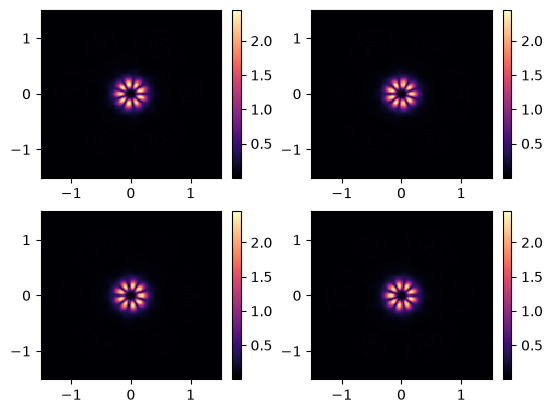

In [17]:
W = wannierdata["wannierstates"]
R = wannierdata["rgrid"]
fig,ax = plt.subplots(2,2)
for i in range(2):
    for j in range(2):
        a = ax[i,j].pcolormesh(R[...,0],R[...,1],(np.abs(W[...,i,j])),cmap='magma')
        plt.colorbar(a)

In [ ]:
X,Y = grid[...,0],grid[...,1]
fig, ax = plt.subplots(subplot_kw={"projection": "3d"},figsize=(6,6))
ax.view_init(elev=80, azim=0, roll=0)
#bandsforplotting = bands.copy()
#bandsforplotting[~condition]=np.nan
maps = ("coolwarm","coolwarm","coolwarm")
for i in range(3):
    ax.plot_surface(X,Y,bands[...,i],cmap=maps[i],alpha=1)
#ax.set_zlim(0.16-0.016,0.16+0.016)

In [49]:
n=3
#fig,ax = plt.subplots(2,2,figsize=(12,12))
#for i in range(2):
#    for j in range(2):
#        a=ax[i,j].imshow(abs(M[:,:,n,i,j]))
        #plt.colorbar(a)
def subspace_overlap(u, v):
    M = np.einsum(
        "...am,...an->...mn",
        u.conj(), v
    )
    return np.sum(np.abs(M)**2, axis=(-2, -1))

zoneshift = bm.zoneshift
q1 = bm.q2
q2 = -bm.q1
psi=flatbands
s = np.linalg.svd(M, compute_uv=False)

print("min singular value:", s[..., 1].min())
print("mean singular value:", s[..., 1].mean())

min singular value: 0.5655628197818756
mean singular value: 0.9955159968159486


In [ ]:
fig,ax = plt.subplots(2,3,figsize=(9,6))
for i in range(2):
    for j in range(3):
        ax[i,j].imshow(abs(wannier[...,i,j]))

In [ ]:
k = bm.hexagonalpath
#Vector valued meshgrid, first coordinate corresponds to k along the usual path, second to q along the same path.
K,Q = k[:,None,:]+0*k[None,:,:],k[None,:,:]+0*k[:,None,:] 
#x = np.linspace(-1+0.001,1,100,endpoint=False)*1/2
#k1 = x[:, None] * (bm.q2[None, :])
#k2 = -bm.q1[None, :] * x[:, None]
Kgrid = grid
print(grid[0,0],grid[-1,0],grid[0,-1])
plt.pcolormesh(Kgrid[...,0],Kgrid[...,1],Kgrid[...,0])
Q = np.zeros_like(Kgrid)+0.2*np.array([0,1])[None,None,:]
#λfactors = interacting.λ_formfactor(Kgrid,Q,N=120,θ=0.72,w=-0.11,
                                    #energy_window=0.016,flatband_energy=0.161,cutoff=9,max_active_bands=3)

In [ ]:
fig,axes = plt.subplots(3,3,figsize=(10,10),sharex=True,sharey=True)
images = []
for i in range(3):
    for j in range(3):
        images.append(axes[i,j].pcolormesh(Kgrid[...,0],Kgrid[...,1],abs(λfactors[...,i,j]),vmin=0,vmax=1,cmap='viridis'))
        #axes[i,j].set_xticks(*bm.pathlabels)
        #axes[i,j].set_yticks(*bm.pathlabels)
for im in images:
    plt.colorbar(im)

In [ ]:
###Play around/edit saved data:
import interacting
import numpy as np
import matplotlib.pyplot as plt
params = {'N':80,
          'θ':0.72,
          'w':-0.11,
          'energy_window':0.016,
          'flatband_energy':0.161,
          'cutoff':9,
          'max_active_bands':3}
key = interacting.make_data_key(params)
path = f"./cache/{key}/data.npz"
with np.load(path) as data:
    for name in data.files:
        print(name)
data = np.load(path)
energies = data["bands"]
states = data["blochstates"]
grid = data["kgrid"]
print(np.shape(energies))
for l in range(0):
    reordering = interacting.band_selection(states[...,:-1])
#for i in range(3):
    #states[...,i] = interacting.gauge_smooth(states[...,i])
    #states[...,i] = np.swapaxes(interacting.gauge_smooth(np.swapaxes(states[...,i],0,1)),0,1)
#for i in range(3):
#    states[:,:10,i] = interacting.gauge_smooth(states[:,:10,i])
#Cut out anomalies outside the central dirac cone:
#momentumfilter = abs(grid[...,1])<0.41
#energies[...,-1] = np.where(momentumfilter,energies[...,-1],np.nan)
#states[...,-1] = np.where(momentumfilter[...,None],states[...,-1],np.nan)

    #states[...,:-1]=np.take_along_axis(states[...,:-1],reordering[:,:,None,:],axis=-1)
#Try to better identify the two flatbands using overlaps:
#print(grid[60,60]) #A reference momentum where the flatbands are well seperated:
refstate = states[40,40,:,:2]
overlap = np.sum(abs(np.sum(refstate.conj()[None,None,:,:,None]*states[:,:,:,None,:],axis=-3))**2,axis=-2)
overlapsort = np.argsort(overlap,axis=-1,descending=True)
#states = np.take_along_axis(states,overlapsort[:,:,None,:],axis=-1)
condition = (overlap<=0.7) & (np.linalg.norm(grid,axis=-1)<0.35)[...,None]
idx,idy,idb = np.where(condition)
#overlap[condition]=0
print(overlap.shape)
#overlap1[np.isnan(overlap1)]=-1
#overlap2 = abs(np.sum(refstate2.conj()[None,None,:,None]*states,axis=-2))
#overlap2[np.isnan(overlap2)]=-1
#fb1_index = np.argmax(overlap1,axis=-1)
#fb2_index = np.argmax(overlap2,axis=-1)
#dirac_index = np.argmin(overlap2+overlap1,axis=-1)
#First sort by summed overlap with BOTH flatbands?
#fb_overlap_descending = np.argsort(overlap1+overlap2,descending=True)
#print(np.shape(fb_overlap_descending))
#states = np.take_along_axis(states,fb_overlap_descending[...,None,:],axis=-1)
#energies = np.take_along_axis(energies,fb_overlap_descending,axis=-1)
#Repeat with overlap with first (arbitrary) flatband:
#refstate1 = states[60,60,:,0]
#overlap1 = abs(np.sum(refstate1.conj()[None,None,:,None]*states,axis=-2))[...,:-1]
#energy_ascending = np.argsort(energies[...,:-1])
#states[...,:-1] = np.take_along_axis(states[...,:-1],energy_ascending[...,None,:],axis=-1)
#energies[...,:-1] = np.take_along_axis(energies[...,:-1],energy_ascending,axis=-1)
fig, axes = plt.subplots(1,3,figsize=(14,6))
#adj_overlap = np.where(~np.isnan(energies),np.sum(np.roll(states,1,axis=0).conj()*states,axis=-2),np.nan)
for i in range(3):
    #a=axes[i].pcolormesh(grid[...,0],grid[...,1],energies[...,i],cmap='seismic')
    a=axes[i].pcolormesh(grid[...,0],grid[...,1],overlap[...,i],cmap='seismic',vmin=0.,vmax=1)
    #a=axes[i].pcolormesh(grid[...,0],grid[...,1],reordering[...,i],cmap='seismic')
    #a = axes[i].pcolormesh(grid[...,0],grid[...,1],np.angle(adj_overlap[...,i]),cmap='hsv')
    plt.colorbar(a)
#a=axes[2].pcolormesh(grid[...,0],grid[...,1],np.abs(adj_overlap[...,1]),cmap='seismic')
###newData = {"blochstates":states,"bands":energies,"kgrid":grid}
###np.savez_compressed(path,**newData)

In [ ]:
r = np.linspace(0.25,4,100)
plt.plot(r,0*r,c='lightgrey')

plt.plot(r,1/r,c='b',label='m/r')
plt.plot(r,2.5-r,c='black',label="E-λr")
plt.plot(r,r-2.5,c='black',linestyle='dotted',label='λr-E')
plt.ylim(-3,3)
plt.xlim(0.25,4)
plt.legend()
plt.yticks([])
plt.xticks([])
plt.xlabel("r")
#kjjplt.savefig("./plots/semiclassical_regions.pdf")

In [ ]:
a =np.random.random((4,4))
bi,bj = np.where(a>0.5)
print(bi,bj)
for i in range(len(bi)):
    print(bi[i],bj[i])
    print(a[bi[i],bj[i]])